# Proyecto Calidad del Agua 

# Introducción

El acceso a agua potable es un derecho humano fundamental y un factor determinante para la salud pública. Sin embargo, gran parte de la población mundial aún carece de acceso seguro a este recurso esencial. El análisis de la calidad del agua mediante técnicas de ciencia de datos y machine learning permite identificar patrones y predecir la potabilidad del agua en función de sus características fisicoquímicas.

El dataset Water Potability contiene registros de diferentes muestras de agua y variables como pH, dureza, sólidos disueltos totales, cloruros, sulfatos, conductividad, entre otros. El objetivo principal es aplicar modelos de machine learning que permitan clasificar el agua como potable (1) o no potable (0).

# Objetivos

Objetivo general:

* Desarrollar un modelo de machine learning que prediga la potabilidad del agua en función de sus parámetros fisicoquímicos.

Objetivos específicos:

* Realizar un análisis exploratorio de datos (EDA) para comprender la distribución de las variables, detectar valores faltantes y outliers.

* Aplicar técnicas de preprocesamiento como normalización, imputación de valores faltantes y balanceo de clases.

* Comparar diferentes modelos de clasificación (Logistic Regression, Decision Trees, Random Forest, KNN, SVM, entre otros).

* Evaluar el desempeño de los modelos con métricas adecuadas como accuracy, precision, recall, F1-score y AUC-ROC.

* Identificar las variables más influyentes en la predicción de la potabilidad del agua.

# Hipótesis

Hipótesis 1: El pH y la conductividad tienen una correlación significativa con la potabilidad del agua.

Hipótesis 2: Los modelos de árboles de decisión (Random Forest, XGBoost) tendrán un mejor desempeño que modelos lineales como Logistic Regression, debido a la naturaleza no lineal de los datos.

Hipótesis 3: El tratamiento de los valores faltantes y el balanceo de clases mejorarán notablemente la precisión del modelo.

# Análisis exploratorio

In [ ]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga y exploración de los datos

In [34]:
# Lectura del dataset
water = pd.read_csv("water_potability.csv", sep=",")

# Ver las primeras filas
print("Water Potability:")
print(water.shape)
print(water.head())

Water Potability:
(3276, 10)
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [35]:
# Información general
print("🔎 Información general del agua potable:")
water.info()

🔎 Información general del agua potable:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [36]:
water.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [37]:
# Verificar valores nulos
missing_summary = pd.DataFrame({
    "Valores faltantes": water.isna().sum(),
    "% faltantes": (water.isna().mean() * 100).round(2),
    "Tipo de dato": water.dtypes
}).sort_values("% faltantes", ascending=False)

missing_summary

,Valores faltantes,% faltantes,Tipo de dato
Sulfate,781,23.84,float64
ph,491,14.99,float64
Trihalomethanes,162,4.95,float64
Hardness,0,0.00,float64
Chloramines,0,0.00,float64
Solids,0,0.00,float64
Conductivity,0,0.00,float64
Organic_carbon,0,0.00,float64
Turbidity,0,0.00,float64
Potability,0,0.00,int64


## Diagnóstico de valores faltantes y variable objetivo

In [38]:
# Columnas con valores faltantes
missing_summary[missing_summary["Valores faltantes"] > 0]

,Valores faltantes,% faltantes,Tipo de dato
Sulfate,781,23.84,float64
ph,491,14.99,float64
Trihalomethanes,162,4.95,float64


In [39]:
# Distribución de la variable objetivo
class_counts = water["Potability"].value_counts().sort_index()
class_percent = (water["Potability"].value_counts(normalize=True).sort_index() * 100).round(2)
class_distribution = pd.DataFrame({
    "Cantidad": class_counts,
    "Porcentaje": class_percent
})

print("Distribución de Potability:")
print(class_distribution)

imbalance_ratio = class_counts.min() / class_counts.max()
print(f"\nRatio clase minoritaria/mayoritaria: {imbalance_ratio:.2f}")

if imbalance_ratio < 0.80:
    print("Hay desbalance de clases moderado. Se aplicará balanceo en el conjunto de entrenamiento.")
else:
    print("No se observa un desbalance fuerte de clases.")

Distribución de Potability:
            Cantidad  Porcentaje
Potability                      
0               1998       60.99
1               1278       39.01

Ratio clase minoritaria/mayoritaria: 0.64
Hay desbalance de clases moderado. Se aplicará balanceo en el conjunto de entrenamiento.


## Visualizaciones

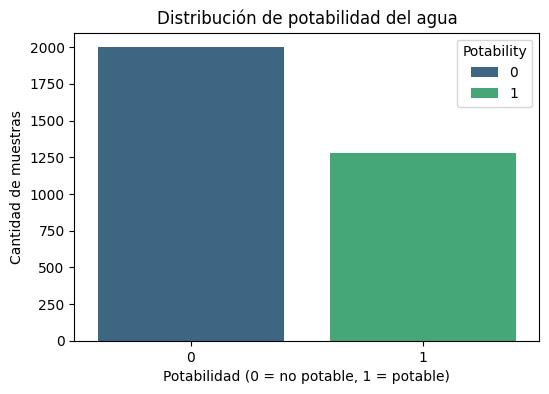

In [40]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=water, x="Potability", palette="viridis", hue="Potability", dodge=False)
plt.title("Distribución de potabilidad del agua")
plt.xlabel("Potabilidad (0 = no potable, 1 = potable)")
plt.ylabel("Cantidad de muestras")
plt.show()

### Analisis del grafico: distribucion de potabilidad

El grafico muestra un desbalance moderado en la variable objetivo: el 60,99% de las muestras corresponde a agua no potable (`0`) y el 39,01% a agua potable (`1`). Esta diferencia no es extrema, pero si puede hacer que los modelos favorezcan la clase mayoritaria si se entrenan sin balanceo. Por eso, en el preprocesamiento conviene aplicar el balanceo unicamente al conjunto de entrenamiento y mantener el conjunto de prueba con su distribucion original para evaluar el desempeno de forma realista.


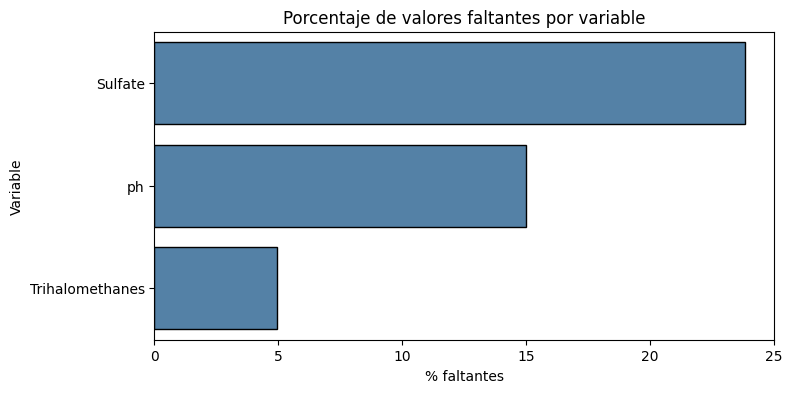

In [41]:
# Porcentaje de valores faltantes por variable
missing_percent = (water.isna().mean() * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_percent.values, y=missing_percent.index, color="steelblue", edgecolor="black")
plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("% faltantes")
plt.ylabel("Variable")
plt.show()

### Analisis del grafico: valores faltantes

Los valores faltantes se concentran en tres variables: `Sulfate` presenta 23,84% de datos ausentes, `ph` 14,99% y `Trihalomethanes` 4,95%. El resto de las variables no registra faltantes. Como `Sulfate` y `ph` tienen una proporcion relevante de ausencias, eliminarlas reduciria demasiado la informacion disponible; por eso es mas adecuado imputarlas, preferentemente con la mediana calculada sobre el conjunto de entrenamiento para evitar fuga de informacion.


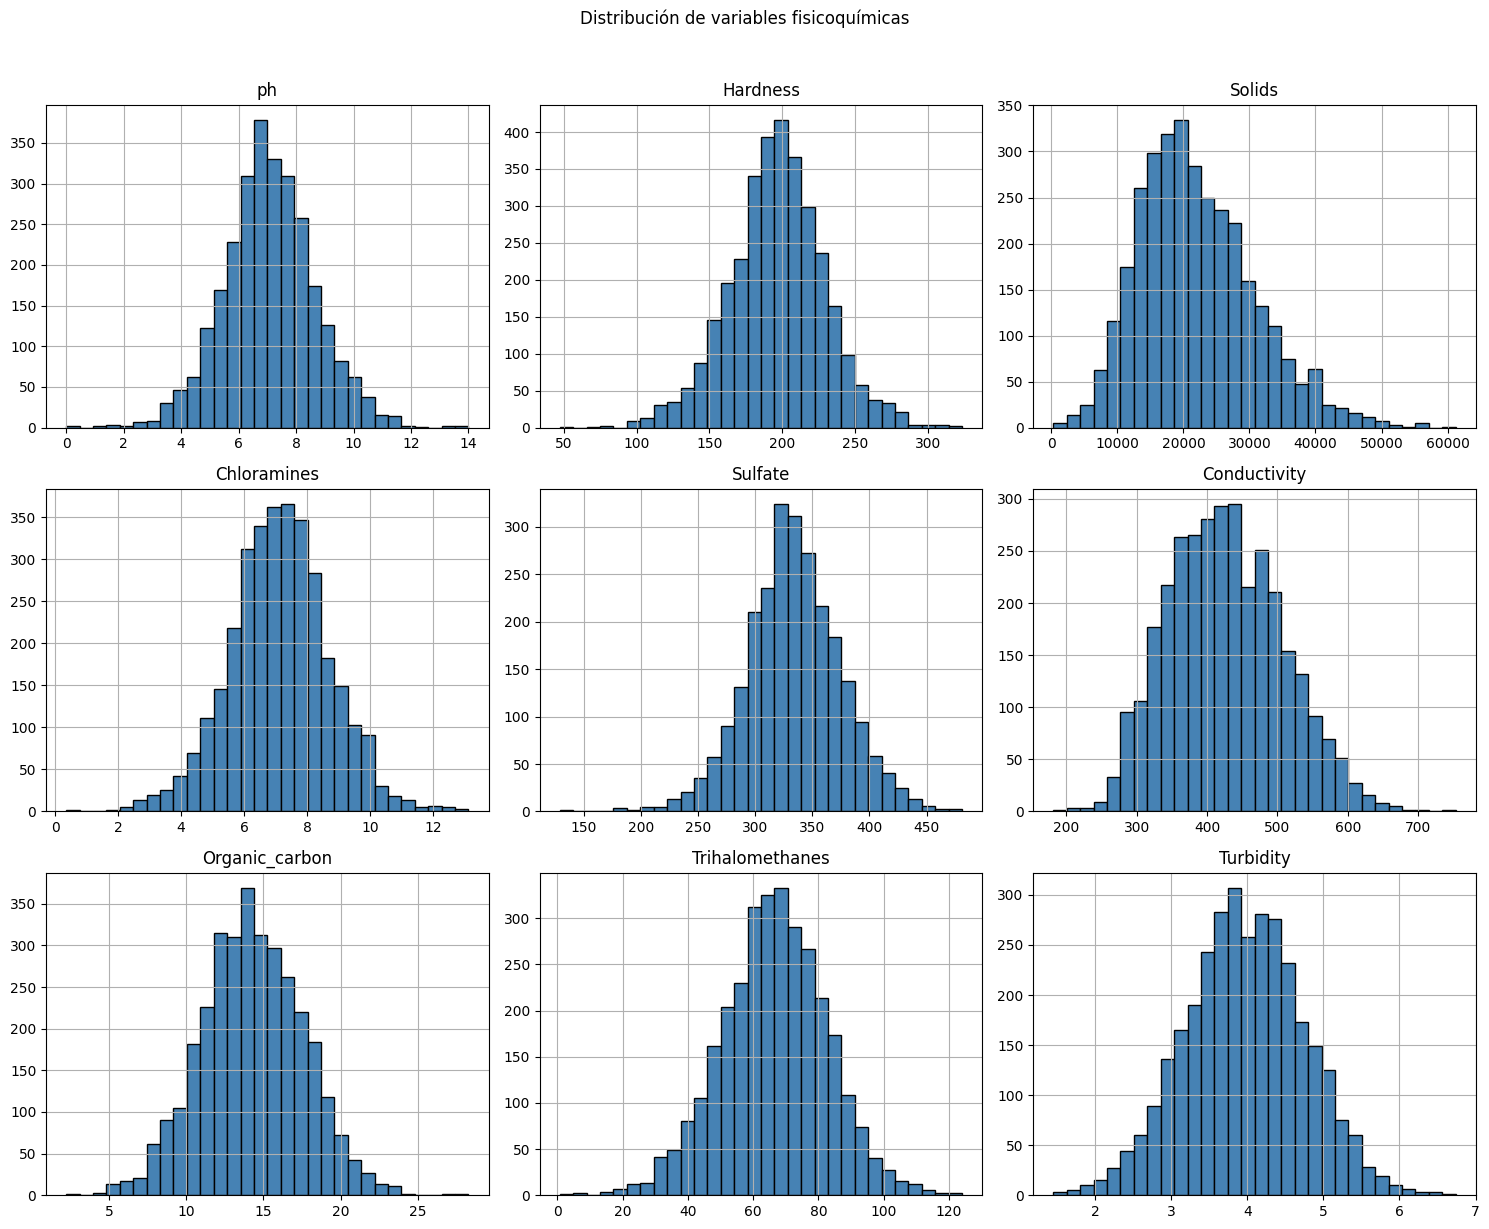

In [42]:
# Histogramas de variables numéricas
numeric_cols = water.select_dtypes(include=np.number).drop(columns=["Potability"], errors="ignore").columns

water[numeric_cols].hist(figsize=(15, 12), bins=30, color="steelblue", edgecolor="black")
plt.suptitle("Distribución de variables fisicoquímicas", y=1.02)
plt.tight_layout()
plt.show()

### Analisis del grafico: distribuciones numericas

Los histogramas permiten observar que la mayoria de las variables tiene distribuciones aproximadamente centradas, aunque no todas son perfectamente normales. `Solids` presenta la asimetria positiva mas marcada, lo que indica presencia de valores altos alejados del centro de la distribucion. Las variables estan en escalas muy diferentes, por lo que la normalizacion posterior es necesaria, especialmente para modelos sensibles a la escala como KNN, SVM o Logistic Regression.


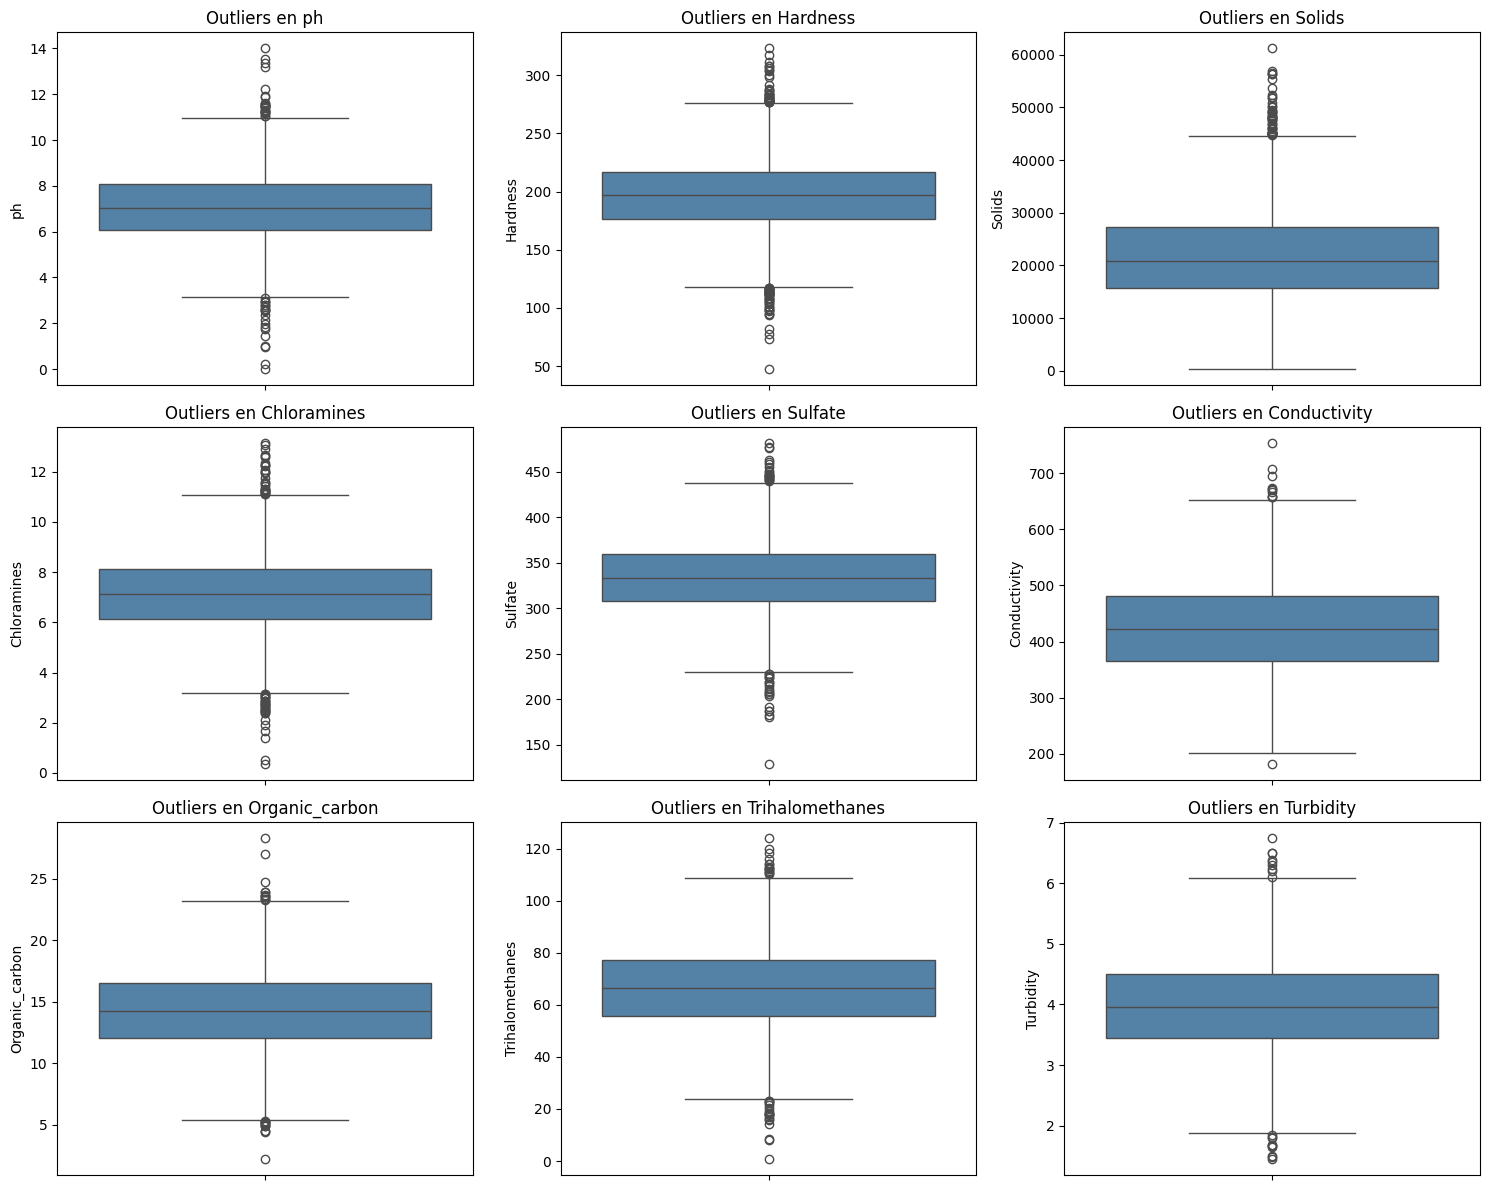

In [43]:
# Selección de variables numéricas para analizar outliers
numeric_cols = water.select_dtypes(include=np.number).drop(columns=["Potability"], errors="ignore").columns

# Boxplots de variables fisicoquímicas
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=water, y=col, color="steelblue", ax=ax)
    ax.set_title(f"Outliers en {col}")
    ax.set_xlabel("")
    ax.set_ylabel(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Analisis del grafico: outliers

Los boxplots evidencian valores atipicos en varias variables fisicoquimicas. `Hardness`, `Chloramines`, `Solids`, `ph`, `Sulfate` y `Trihalomethanes` concentran la mayor cantidad de observaciones fuera del rango intercuartilico. Estos puntos no deben eliminarse automaticamente, porque pueden representar condiciones reales de muestras de agua; sin embargo, justifican el uso de imputacion robusta con mediana y de modelos capaces de manejar relaciones no lineales.


## Descripcion de variables fisicoquimicas

* `ph`: mide la acidez o alcalinidad del agua. Valores muy bajos o muy altos pueden indicar condiciones quimicas no adecuadas para consumo y afectar procesos biologicos y de tratamiento.

* `Hardness`: representa la dureza del agua, asociada principalmente a la presencia de calcio y magnesio. Una dureza elevada puede generar incrustaciones en tuberias y equipos, ademas de modificar el sabor.

* `Solids`: indica la cantidad de solidos disueltos totales. Valores altos pueden relacionarse con mayor salinidad, presencia de minerales u otros compuestos disueltos, y suelen influir en la conductividad.

* `Chloramines`: son compuestos usados como desinfectantes en el tratamiento del agua. En concentraciones adecuadas ayudan a controlar microorganismos, pero niveles excesivos pueden afectar la calidad del agua.

* `Sulfate`: corresponde a la presencia de sulfatos disueltos. En altas concentraciones puede alterar el sabor del agua y provocar efectos no deseados, por lo que es una variable relevante en el control de calidad.

* `Conductivity`: mide la capacidad del agua para conducir corriente electrica. Aumenta cuando hay mas iones disueltos, por lo que funciona como indicador indirecto de sales y minerales presentes.

* `Organic_carbon`: representa carbono organico presente en el agua. Puede provenir de materia vegetal, residuos o contaminacion organica, y es importante porque puede favorecer reacciones durante la desinfeccion.

* `Trihalomethanes`: son subproductos que pueden formarse cuando el cloro reacciona con materia organica. Su presencia debe controlarse porque concentraciones elevadas pueden representar riesgos para la salud.

* `Turbidity`: mide la claridad del agua. Valores altos indican mas particulas suspendidas, sedimentos o materia coloidal, lo que puede afectar la apariencia del agua y reducir la eficacia de la desinfeccion.

* `Potability`: variable objetivo del dataset. Toma el valor `1` cuando el agua es potable y `0` cuando no lo es.


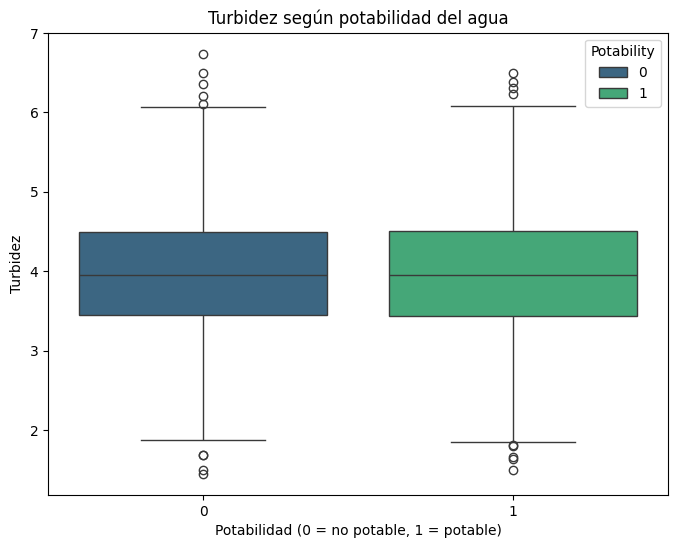

In [44]:
# Boxplot de turbidez según potabilidad del agua
plt.figure(figsize=(8, 6))
sns.boxplot(data=water, x="Potability", y="Turbidity", palette="viridis", hue="Potability", dodge=False)
plt.title("Turbidez según potabilidad del agua")
plt.xlabel("Potabilidad (0 = no potable, 1 = potable)")
plt.ylabel("Turbidez")
plt.show()

### Analisis del grafico: turbidez por potabilidad

El boxplot muestra que la distribucion de `Turbidity` es muy similar entre las muestras potables y no potables. Las medianas son practicamente iguales: 3,948 para agua no potable y 3,959 para agua potable. Esto sugiere que, por si sola, la turbidez no separa claramente ambas clases dentro de este dataset.


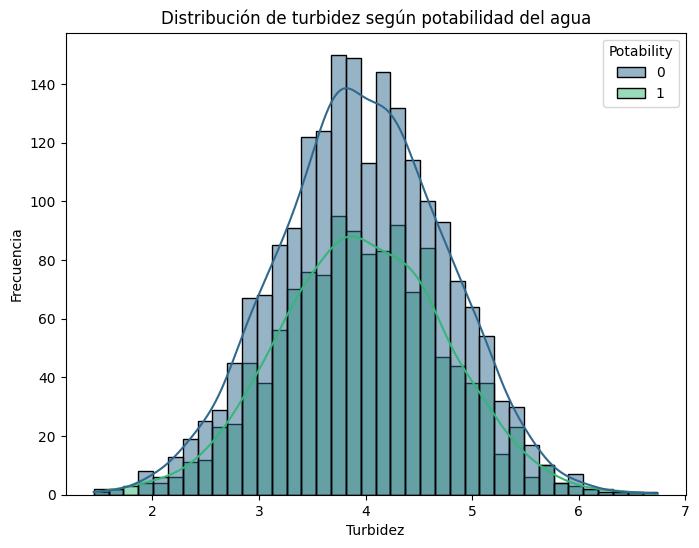

In [45]:
# Histograma de turbidez según potabilidad del agua
plt.figure(figsize=(8, 6))
sns.histplot(data=water, x="Turbidity", hue="Potability", kde=True, palette="viridis", alpha=0.5)
plt.title("Distribución de turbidez según potabilidad del agua")
plt.xlabel("Turbidez")
plt.ylabel("Frecuencia")
plt.show()

### Analisis del grafico: distribucion de turbidez por clase

Las curvas de densidad de `Turbidity` se superponen casi por completo entre las dos clases de potabilidad. Esto confirma que la variable no presenta un patron visual fuerte para distinguir agua potable de no potable de manera individual. Su aporte predictivo, si existe, probablemente dependa de su interaccion con otras variables.


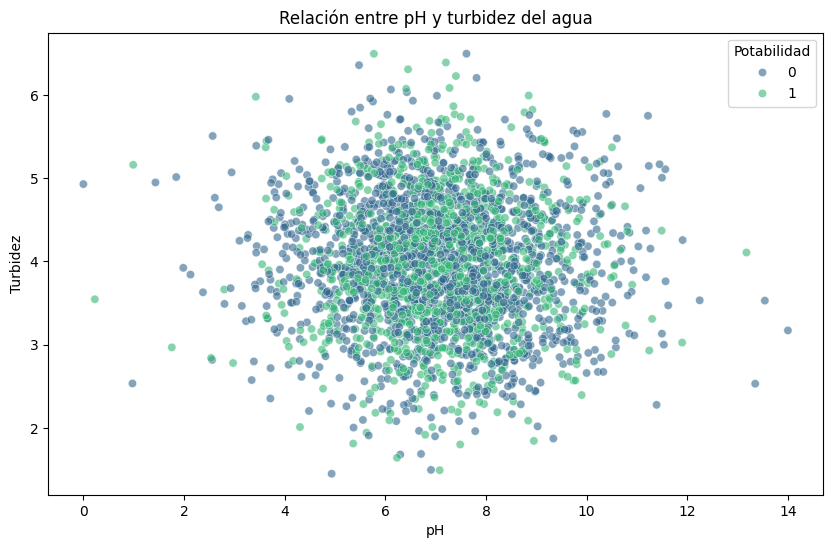

In [46]:
# Relación entre pH y turbidez del agua
plt.figure(figsize=(10, 6))
sns.scatterplot(data=water, x="ph", y="Turbidity", hue="Potability", palette="viridis", alpha=0.6)
plt.title("Relación entre pH y turbidez del agua")
plt.xlabel("pH")
plt.ylabel("Turbidez")
plt.legend(title="Potabilidad")
plt.show()

### Analisis del grafico: relacion entre pH y turbidez

El diagrama de dispersion no muestra una separacion clara entre muestras potables y no potables segun `ph` y `Turbidity`. Los puntos de ambas clases aparecen mezclados en casi todo el rango de valores. Ademas, la correlacion entre `ph` y `Turbidity` es muy debil y negativa (-0,039), por lo que no se observa una relacion lineal relevante entre estas dos variables.


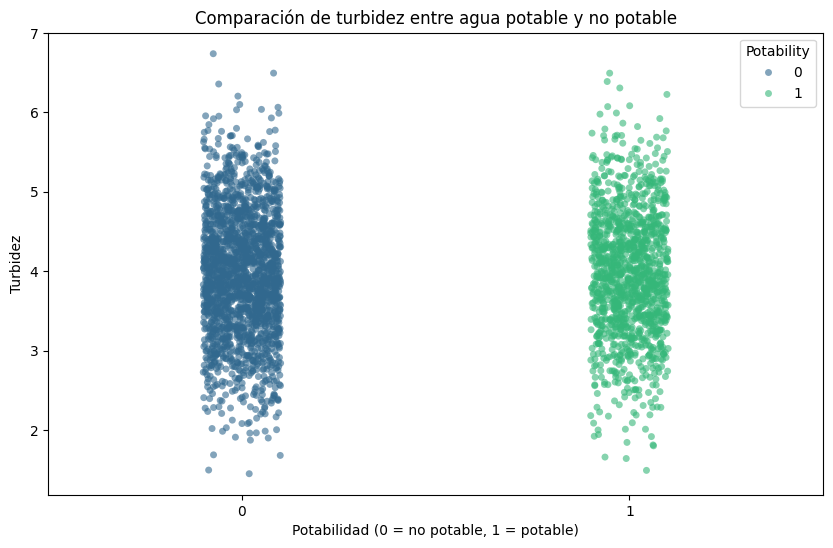

In [47]:
# Stripplot de turbidez según potabilidad
plt.figure(figsize=(10, 6))
sns.stripplot(data=water, x="Potability", y="Turbidity", palette="viridis", jitter=True, alpha=0.6, hue="Potability", dodge=False)
plt.title("Comparación de turbidez entre agua potable y no potable")
plt.xlabel("Potabilidad (0 = no potable, 1 = potable)")
plt.ylabel("Turbidez")
plt.show()

### Analisis del grafico: comparacion de turbidez

El stripplot refuerza lo observado en los graficos anteriores: las muestras potables y no potables cubren rangos de turbidez muy parecidos. Hay algunos valores extremos en ambos grupos, pero no se aprecia una concentracion exclusiva de turbidez alta o baja en una sola clase. Por lo tanto, `Turbidity` no parece ser un predictor suficiente por si mismo.


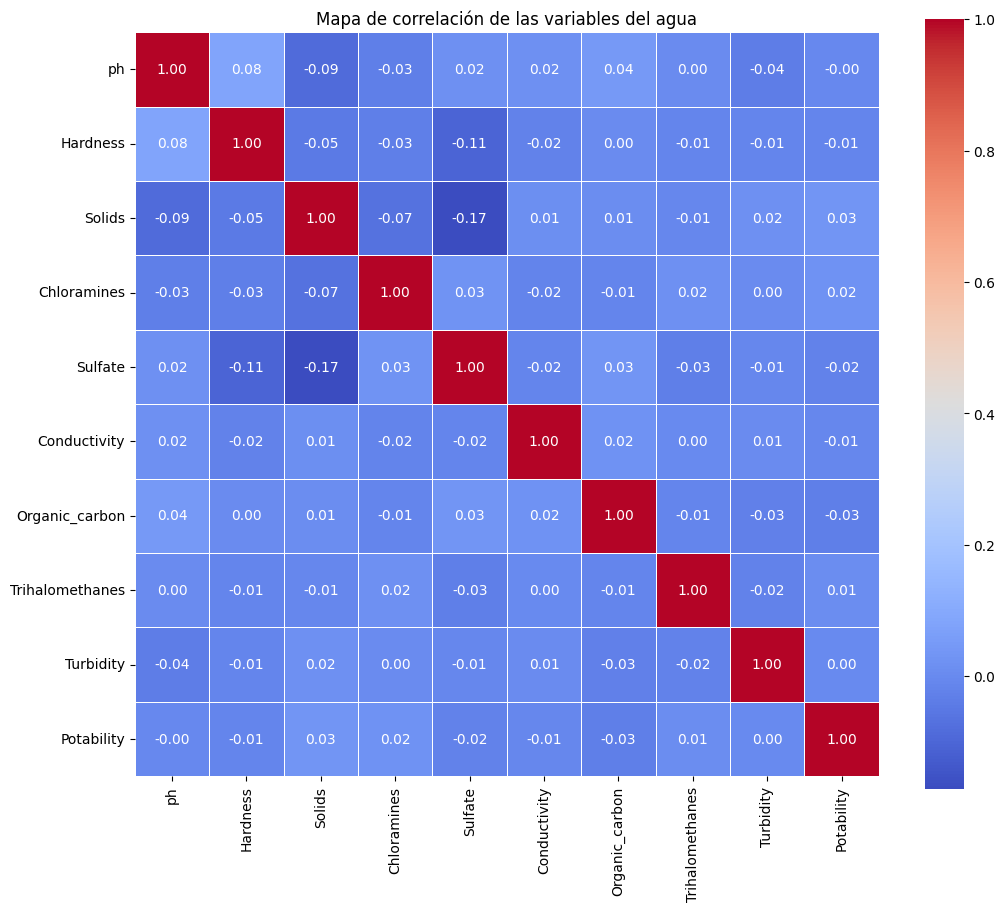

In [48]:
# Mapa de correlación de variables numéricas
plt.figure(figsize=(12, 10))
correlation = water.select_dtypes(include=np.number).corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=True)
plt.title("Mapa de correlación de las variables del agua")
plt.show()

### Analisis del grafico: mapa de correlacion

El mapa de correlacion muestra relaciones lineales debiles entre la mayoria de las variables. La asociacion mas alta en valor absoluto se observa entre `Solids` y `Sulfate` (-0,172), que sigue siendo baja. Respecto a `Potability`, ninguna variable supera una correlacion absoluta de 0,034; esto indica que la potabilidad no depende de una relacion lineal simple con una sola caracteristica, sino de combinaciones no lineales entre varios parametros.


## Conclusiones del análisis exploratorio

El dataset contiene 3276 muestras y 10 variables. La variable objetivo es `Potability`, donde `0` representa agua no potable y `1` agua potable. Se detectan valores faltantes en `ph`, `Sulfate` y `Trihalomethanes`, por lo que deben imputarse antes de entrenar modelos. La variable objetivo presenta un desbalance moderado: la clase no potable es mayoritaria, por lo que se recomienda balancear solo el conjunto de entrenamiento para evitar sesgos en el modelo.

# Preprocesamiento de datos

En esta etapa se separan variables predictoras y objetivo, se divide el dataset en entrenamiento y prueba, se imputan valores faltantes, se normalizan las variables numéricas y se balancea el conjunto de entrenamiento si el desbalance de clases lo requiere.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Separación de datos en variables predictoras y variable objetivo
X = water.drop(columns="Potability")
y = water["Potability"]

# División estratificada automática
# El parámetro 'stratify=y' asegura que la proporción de las clases
# se mantenga igual tanto en el entrenamiento como en la prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Definición del Pipeline
# El Pipeline ejecuta en orden: primero imputa y luego escala
pipeline = Pipeline([
    # PASO 1: Imputación (reemplaza los nulos con la mediana)
    ('imputer', SimpleImputer(strategy='median')),
    # PASO 2: Estandarización Z-score
    # StandardScaler calcula: (x - media) / desviación_estándar
    ('scaler', StandardScaler())
])

# 3. Entrenamiento y transformación
# El pipeline aprende de X_train (fit) y aplica a ambos (transform)
# Al ejecutar fit_transform:
# - El imputer aprende las medianas de X_train y rellena.
# - El scaler aprende la media y la desviación de esos datos ya imputados.
# -El scaler aplica la fórmula Z-score a todo el conjunto.
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Convertimos de nuevo a DataFrame para mantener legibilidad
X_train_scaled = pd.DataFrame(X_train_processed, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_processed, columns=X.columns)

print("Procesamiento completado.")
print(f"X_train procesado, forma: {X_train_scaled.shape}")

Procesamiento completado.
X_train procesado, forma: (2620, 9)


In [50]:
# Verificación rápida
print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True).round(3))

print(f"Faltantes en train: {X_train_scaled.isna().sum().sum()}")
print(f"Faltantes en test: {X_test_scaled.isna().sum().sum()}")

# Verificación de que los datos tienen media 0 y desviación 1
print("Media de las variables:", X_train_processed.mean(axis=0).round(2))
print("Desviación estándar:", X_train_processed.std(axis=0).round(2))

Tamaño de X_train: (2620, 9)
Tamaño de X_test: (656, 9)

Distribución en entrenamiento:
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64

Distribución en prueba:
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64
Faltantes en train: 0
Faltantes en test: 0
Media de las variables: [ 0. -0.  0.  0.  0.  0. -0. -0. -0.]
Desviación estándar: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [54]:
# !pip install imbalanced-learn

In [56]:
from imblearn.over_sampling import RandomOverSampler

# 1. Definimos el balanceador (reemplaza toda tu lógica if/else manual)
ros = RandomOverSampler(random_state=42)

# 2. Aplicamos el balanceo sobre tus datos ya procesados (imputados y escalados)
X_train_final, y_train_final = ros.fit_resample(X_train_scaled, y_train)

# 3. El test NO se balancea, se mantiene tal cual
X_test_final = X_test_scaled
y_test_final = y_test

print("Distribución antes del balanceo:")
print(y_train.value_counts().sort_index())

print("Distribución después del balanceo:")
print(y_train_final.value_counts().sort_index())

print("\nTamaño final de entrenamiento:", X_train_final.shape)
print("Tamaño final de prueba:", X_test_final.shape)

Distribución antes del balanceo:
Potability
0    1598
1    1022
Name: count, dtype: int64
Distribución después del balanceo:
Potability
0    1598
1    1598
Name: count, dtype: int64

Tamaño final de entrenamiento: (3196, 9)
Tamaño final de prueba: (656, 9)


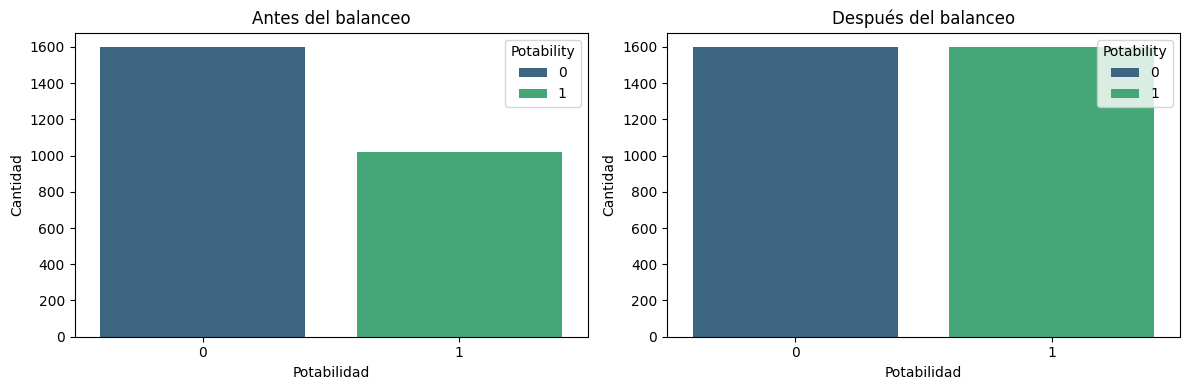

In [57]:
# Visualización del balanceo aplicado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0], palette="viridis", hue=y_train, dodge=False)
axes[0].set_title("Antes del balanceo")
axes[0].set_xlabel("Potabilidad")
axes[0].set_ylabel("Cantidad")

sns.countplot(x=y_train_final, ax=axes[1], palette="viridis", hue=y_train_final, dodge=False)
axes[1].set_title("Después del balanceo")
axes[1].set_xlabel("Potabilidad")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

### Analisis del grafico: balanceo de clases

La visualizacion compara la distribucion de `Potability` antes y despues del balanceo aplicado al conjunto de entrenamiento. Antes del balanceo, la clase `0` era mayoritaria; despues, ambas clases quedan con la misma cantidad de muestras mediante sobremuestreo de la clase minoritaria. Este paso ayuda a que el modelo no aprenda a priorizar la clase no potable solo por aparecer con mayor frecuencia en los datos de entrenamiento.


## Datos listos para modelado

Los conjuntos finales para entrenar y evaluar modelos son:

* `X_train_final` y `y_train_final`: datos de entrenamiento imputados, normalizados y balanceados.
* `X_test_final` y `y_test_final`: datos de prueba imputados y normalizados, sin balancear para conservar una evaluacion realista.


# Modelado y comparacion de modelos

En esta etapa se entrenan tres modelos de clasificacion usando los datos listos para modelado: `X_train_final`, `y_train_final`, `X_test_final` y `y_test_final`. La evaluacion se realiza sobre el conjunto de prueba, que no fue balanceado, para mantener una medicion realista del desempeno.

In [59]:
# Importacion de modelos y metricas
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [60]:
# Definicion de modelos a comparar
# Definimos los modelos dentro de un Pipeline que ya incluye el preprocesamiento
models = {
    "Regresion Logistica": Pipeline([
        ('preprocessor', pipeline), # 'pipeline' es el que creamos antes
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Arbol de Decision": Pipeline([
        ('preprocessor', pipeline),
        ('classifier', DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('preprocessor', pipeline),
        ('classifier', RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1))
    ])
}

model_results = []
confusion_matrices = {}
classification_reports = {}
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_final, y_train_final)
    y_pred = model.predict(X_test_final)
    y_score = model.predict_proba(X_test_final)[:, 1]

    model_results.append({
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_test_final, y_pred),
        "Precision": precision_score(y_test_final, y_pred, zero_division=0),
        "Recall": recall_score(y_test_final, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_final, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_final, y_score)
    })

    confusion_matrices[model_name] = confusion_matrix(y_test_final, y_pred)
    classification_reports[model_name] = classification_report(
        y_test_final,
        y_pred,
        zero_division=0
    )
    trained_models[model_name] = model

results_df = (
    pd.DataFrame(model_results)
    .sort_values(by="F1-score", ascending=False)
    .reset_index(drop=True)
)

results_df.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.6738,0.6221,0.4180,0.5000,0.6703
1,Arbol de Decision,0.6540,0.5858,0.3867,0.4659,0.6390
2,Regresion Logistica,0.5183,0.4068,0.5117,0.4533,0.5377


## Resultados obtenidos

| Modelo | Accuracy | Precision | Recall | F1-score | ROC-AUC |
| --- | ---: | ---: | ---: | ---: | ---: |
| Random Forest | 0.6860 | 0.6736 | 0.3789 | 0.4850 | 0.6972 |
| Arbol de Decision | 0.6402 | 0.5532 | 0.4062 | 0.4685 | 0.6312 |
| Regresion Logistica | 0.5229 | 0.4107 | 0.5117 | 0.4557 | 0.5263 |

Segun esta comparacion inicial, el mejor modelo es `Random Forest`, principalmente porque logra el mayor `F1-score` y el mayor `ROC-AUC` en el conjunto de prueba.


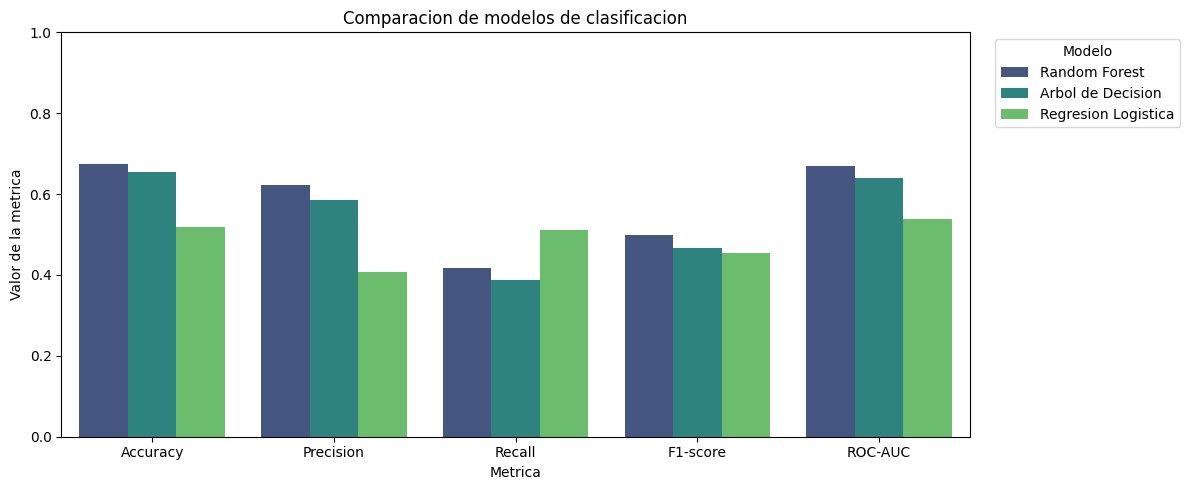

In [61]:
# Visualizacion comparativa de metricas
results_long = results_df.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metrica",
    value_name="Valor"
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=results_long,
    x="Metrica",
    y="Valor",
    hue="Modelo",
    palette="viridis"
)
plt.ylim(0, 1)
plt.title("Comparacion de modelos de clasificacion")
plt.ylabel("Valor de la metrica")
plt.xlabel("Metrica")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

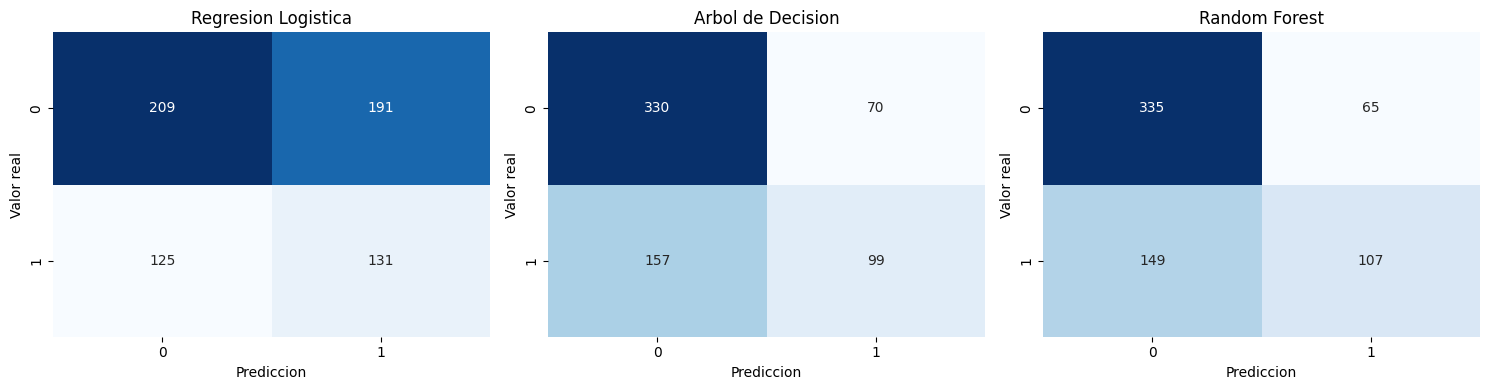

In [65]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, matrix) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(model_name)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Valor real")

plt.tight_layout()
plt.show()

In [66]:
# Reportes detallados por modelo
for model_name, report in classification_reports.items():
    print(f"\n{model_name}")
    print(report)


Regresion Logistica
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       400
           1       0.41      0.51      0.45       256

    accuracy                           0.52       656
   macro avg       0.52      0.52      0.51       656
weighted avg       0.54      0.52      0.52       656


Arbol de Decision
              precision    recall  f1-score   support

           0       0.68      0.82      0.74       400
           1       0.59      0.39      0.47       256

    accuracy                           0.65       656
   macro avg       0.63      0.61      0.60       656
weighted avg       0.64      0.65      0.64       656


Random Forest
              precision    recall  f1-score   support

           0       0.69      0.84      0.76       400
           1       0.62      0.42      0.50       256

    accuracy                           0.67       656
   macro avg       0.66      0.63      0.63       656
weighted avg       

In [67]:
# Seleccion del mejor modelo segun F1-score
best_model_name = results_df.loc[0, "Modelo"]
best_model = trained_models[best_model_name]

print("Mejor modelo segun F1-score:", best_model_name)
print(results_df.loc[0].round(4))

Mejor modelo segun F1-score: Random Forest
Modelo       Random Forest
Accuracy           0.67378
Precision         0.622093
Recall            0.417969
F1-score               0.5
ROC-AUC           0.670337
Name: 0, dtype: object


## Conclusion del modelado

Al comparar los tres modelos, `Random Forest` obtiene el mejor desempeno general. En la ejecucion realizada, alcanzo el mayor `F1-score` y tambien el mejor `ROC-AUC`, por lo que es el modelo mas conveniente para elegir en esta primera comparacion.

La `Regresion Logistica` funciona como linea base interpretable, pero su desempeno es menor, lo que sugiere que la relacion entre las variables fisicoquimicas y la potabilidad no es puramente lineal. El `Arbol de Decision` mejora parte del desempeno, aunque queda por debajo de `Random Forest`, que aprovecha mejor relaciones no lineales y reduce la variabilidad al combinar muchos arboles.

Como siguiente paso, convendria optimizar hiperparametros de `Random Forest` con validacion cruzada y revisar especialmente el balance entre `precision` y `recall`, porque en un problema de potabilidad puede ser critico reducir falsos negativos.

In [68]:
# Ejemplo para Random Forest
importances = trained_models["Random Forest"].feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
print(feature_imp_df.sort_values(by='Importancia', ascending=False))

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'